# groupby · merge · pivot_table
### pivotando agregações e visualizando resultados com gráficos

**Objetivos da aula:** usar `groupby` com múltiplas colunas, `agg()` com várias funções, `merge` para cruzar tabelas, `pivot_table` para relatórios cruzados e plotar gráficos com `matplotlib`.


## Bloco 0 — Setup
Carregue a mesma base usada na semana passada e prepare o notebook para todos os exercícios desta aula.


In [3]:
'''
NUMPY = Motor de computação científica em Python, que oferece suporte a arrays multidimensionais e uma variedade de funções matemáticas para operações eficientes. Ele é amplamente utilizado para manipulação de dados, análise numérica e processamento de grandes conjuntos de dados. O NumPy é fundamental para muitas bibliotecas de ciência de dados e aprendizado de máquina, como pandas, SciPy e scikit-learn.
PANDAS = Biblioteca de código aberto para análise e manipulação de dados em Python. Ela fornece estruturas de dados flexíveis, como DataFrames, que facilitam a manipulação, limpeza e análise de dados. O pandas é amplamente utilizado para tarefas como leitura e escrita de arquivos, filtragem, agrupamento e visualização de dados.
MATPLOTLIB = Biblioteca de visualização de dados em Python, que permite criar gráficos estáticos, animados e interativos. O Matplotlib é amplamente utilizado para criar uma variedade de gráficos, como gráficos de linha, barras, dispersão e histogramas. Ele é altamente personalizável e pode ser integrado com outras bibliotecas, como NumPy e pandas, para criar visualizações complexas e informativas.

Pandas  vai facilitar:
1. filtros - selecionar linhas com base em condições específicas, como "todos os funcionários com salário acima de 5000" ou "todos os funcionários que foram admitidos após 01/01/2020". Isso é feito usando expressões booleanas para criar máscaras de filtragem.
2. joins - combinar dados de diferentes fontes com base em chaves comuns, como "combinar a tabela de funcionários com a tabela de departamentos usando o ID do departamento". O pandas oferece funções como merge() e join() para realizar essas operações de forma eficiente.
3. groupby - agrupar dados com base em uma ou mais colunas e aplicar funções de agregação, como "calcular a média salarial por departamento" ou "contar o número de funcionários por cargo". O método groupby() do pandas facilita essas operações, permitindo que você aplique funções de agregação personalizadas ou pré-definidas.
4. tabelas - manipular e analisar dados tabulares, como "calcular a média salarial por departamento" ou "contar o número de funcionários por cargo". O pandas oferece uma estrutura de dados chamada DataFrame, que é ideal para trabalhar com dados tabulares. Ele permite realizar operações como filtragem, agrupamento, ordenação e agregação de forma eficiente e intuitiva.

'''

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# URL da planilha que usamos nesta aula
URL = (
    "https://raw.githubusercontent.com/"
    "cfneves/turma-visualizacao-de-dados/"
    "master/alunos/orlando_castro/semana_04/bases/base_rh.xlsx"
)

# Lê o arquivo Excel diretamente da internet
df = pd.read_excel(URL)

# Converte a coluna de data de admissão para o tipo datetime
df["Data_Admissao"] = pd.to_datetime(
    df["Data_Admissao"],
    format="%d/%m/%Y",
    errors="coerce"
)

# Mostra quantas linhas e colunas temos e os tipos de cada coluna
print(f"Dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(df.dtypes)


Dataset: 1000 linhas x 10 colunas
ID_Funcionario             int64
Nome                      object
Departamento              object
Cargo                     object
Salario                  float64
Data_Admissao     datetime64[ns]
Genero                    object
Idade                      int64
Estado_Civil              object
Status                    object
dtype: object


## Bloco 1 — groupby: agrupando e resumindo dados
groupby funciona como o `GROUP BY` do SQL: você escolhe colunas para agrupar, escolhe o valor a calcular e escolhe a função de agregação.


### Exemplo 01 — resumo salarial por departamento
Use `groupby` em uma coluna e `agg()` com múltiplas funções para obter uma tabela resumida.


In [ ]:
# Agrupa o DataFrame por departamento e calcula várias estatísticas de salário
# As funções de agregação são aplicadas à coluna "Salario" para cada departamento, e os resultados são arredondados para 2 casas decimais
# São funções padrão do pandas, mas também é possível usar funções personalizadas

resumo = (
    df.groupby("Departamento")["Salario"]
    .agg(
        quantidade="count",  # conta quantos funcionários existem em cada departamento
        media="mean",       # calcula o salário médio
        mediana="median",   # calcula o salário mediano
        minimo="min",       # encontra o salário mais baixo
        maximo="max"        # encontra o salário mais alto
    )
    .round(2)
    .sort_values("media", ascending=False)  # ordena do maior para o menor salário médio
    .reset_index()  # transforma o índice gerado pelo groupby em colunas normais
)

print(resumo.to_string(index=False))


Departamento  quantidade   media  mediana  minimo   maximo
    Produção         182 8968.73  9228.67 2001.65 14951.53
   Logística         156 8881.66  8837.74 2000.71 14889.69
          RH         166 8791.58  8790.54 2224.18 14942.39
  Financeiro         189 8333.12  8180.49 2134.47 14942.48
      Vendas         160 8317.08  8166.78 2016.61 14954.51
          TI         147 8142.91  7927.06 2013.79 14762.59


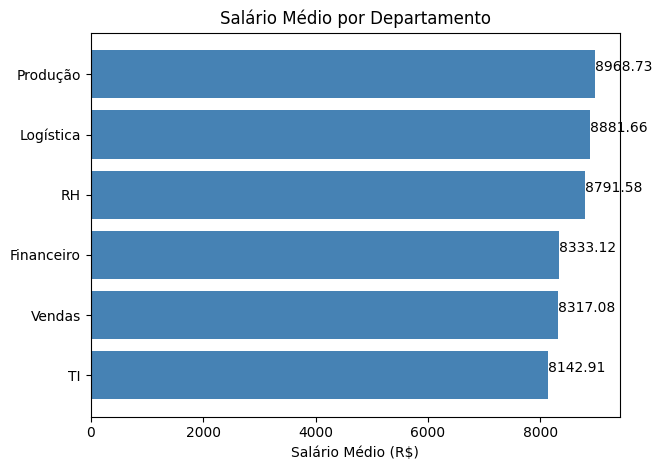

In [5]:
# Ordena do menor para o maior para que o gráfico horizontal seja legível
dados = resumo.sort_values("media")

barras = plt.barh(dados["Departamento"], dados["media"], color="steelblue")
plt.title("Salário Médio por Departamento")
plt.xlabel("Salário Médio (R$)")
plt.tight_layout()
# adiciona rótulos
for barra in barras:
    largura = barra.get_width()
    plt.text(
        largura,
        barra.get_y() + barra.get_height()/2,
        f'{largura}',
        ha='left',
        va='bottom'
    )
plt.show()


### O que este gráfico mostra?
- Cada barra mostra o salário médio de um departamento.
- Barras mais longas significam salários médios maiores.
### Como ler?
- A barra mais longa indica o departamento que paga mais.
- A barra mais curta indica o departamento que paga menos.
### Por que isso importa?
- Ajuda a comparar salários entre departamentos.
- Mostra onde pode ser necessário ajustar ou revisar os pagamentos.

### Exemplo 02 — groupby com duas colunas
Agrupe por duas colunas para obter visões cruzadas e use `unstack()` quando precisar de um formato de tabela para gráficos agrupados.


In [8]:
# Conta quantos funcionários existem em cada combinação Departamento + Status
headcount = (
    df.groupby(["Departamento", "Status"])["ID_Funcionario"]
    .count()
    .reset_index()
    .rename(columns={"ID_Funcionario": "Quantidade"})
)

print(headcount.to_string(index=False))

# Calcula o salário médio por departamento e gênero
sal_genero = (
    df.groupby(["Departamento", "Genero"])["Salario"]
    .mean()
    .round(2)
    .reset_index()
)

print("\nSalário médio por Depto e Gênero (5 primeiras):")
print(sal_genero.head(6).to_string(index=False))


Departamento  Status  Quantidade
  Financeiro   Ativo          96
  Financeiro Inativo          93
   Logística   Ativo          71
   Logística Inativo          85
    Produção   Ativo         100
    Produção Inativo          82
          RH   Ativo          92
          RH Inativo          74
          TI   Ativo          71
          TI Inativo          76
      Vendas   Ativo          85
      Vendas Inativo          75

Salário médio por Depto e Gênero (5 primeiras):
Departamento Genero  Salario
  Financeiro      F  8467.26
  Financeiro      M  8208.56
   Logística      F  8843.49
   Logística      M  8944.41
    Produção      F  8797.64
    Produção      M  9118.66


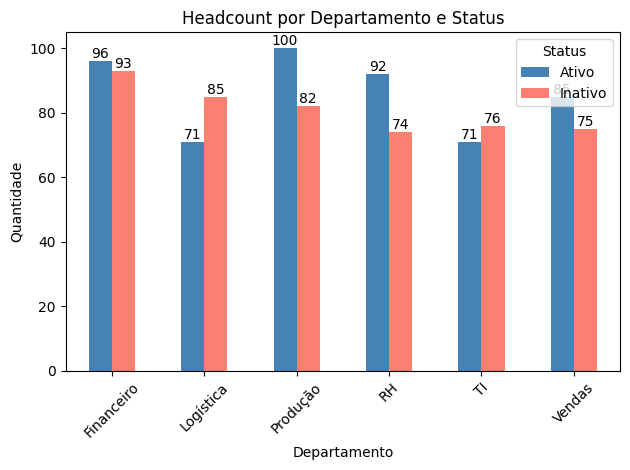

In [12]:
# Reusa o groupby anterior e transforma o segundo nível do índice em colunas
hc_pivot = (
    df.groupby(["Departamento", "Status"])["ID_Funcionario"]
    #df.groupby(["Departamento", "Genero"])["ID_Funcionario"]   # para calcular por gênero em vez de status
    .count()
    .unstack(fill_value=0)
)

# Cada coluna criada por unstack vira uma série no gráfico de barras agrupadas
barras = hc_pivot.plot(kind="bar", color=["steelblue", "salmon"])
plt.title("Headcount por Departamento e Status")
plt.xlabel("Departamento")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.legend(title="Status")
plt.tight_layout()
#Inserir rótulos
for container in barras.containers:
    barras.bar_label(container) 
plt.show()


A diferença entre as duas forma de inserir os rótulos é **simplicidade vs. controle manual**:

#### ❌ Código anterior (manual)
```python
for barra in barras:
    largura = barra.get_width()
    plt.text(
        largura,
        barra.get_y() + barra.get_height()/2,
        f'{largura}',
        ha='left',
        va='bottom'
    )
```
- Itera cada **barra individualmente**
- Calcula manualmente posição (X, Y) e alinhamento
- Mais **verbose** (código longo)
- Oferece **controle fino** sobre posicionamento

#### ✅ Código novo (automático)
```python
for container in barras.containers:
    barras.bar_label(container)
```
- Itera por **grupos de barras** (containers)
- O matplotlib calcula tudo **automaticamente**
- Muito mais **conciso**
- **Ideal para gráficos agrupados** (como o seu, com Status colorido)

#### 🎯 Quando usar cada um?

| Situação | Use |
|----------|-----|
| Gráfico simples, uma série | `bar_label()` (mais simples) |
| Gráfico agrupado/empilhado | `bar_label()` (funciona melhor) |
| Precisa de formato customizado (cores, decimais específicas) | `plt.text()` (mais controle) |

**No seu caso**, o `bar_label()` é **muito melhor** porque:
- Funciona perfeitamente com barras lado a lado (Status Ativo/Inativo)
- Coloca os rótulos automaticamente no topo de cada barra
- Código mais limpo e fácil de manter

### O que este gráfico mostra?
- Cada grupo de barras mostra um departamento.
- Cada cor representa um status diferente, por exemplo ativo ou inativo.
### Como ler?
- Compare as barras de cores diferentes dentro do mesmo departamento.
- Uma barra maior mostra mais pessoas naquele status.
### Por que isso importa?
- Ajuda a ver quantas pessoas existem em cada departamento.
- Mostra se um departamento tem muitos funcionários inativos ou poucos ativos.

### Exemplo 03 — groupby temporal com gráfico de linha
Quando o agrupamento envolve tempo, o gráfico de linha mostra tendência melhor que barras.


In [13]:
# Extrai o ano da data de admissão para poder agrupar por ano
df["Ano_Admissao"] = df["Data_Admissao"].dt.year

# Conta quantos funcionários foram admitidos em cada ano
admissoes_ano = (
    df.groupby("Ano_Admissao")["ID_Funcionario"]
    .count()
    .reset_index()
    .rename(columns={"ID_Funcionario": "Admissoes"})
    .sort_values("Ano_Admissao")
)

print(admissoes_ano.to_string(index=False))


 Ano_Admissao  Admissoes
         2015         33
         2016         87
         2017         99
         2018         89
         2019        101
         2020         94
         2021         94
         2022        108
         2023        106
         2024        113
         2025         76


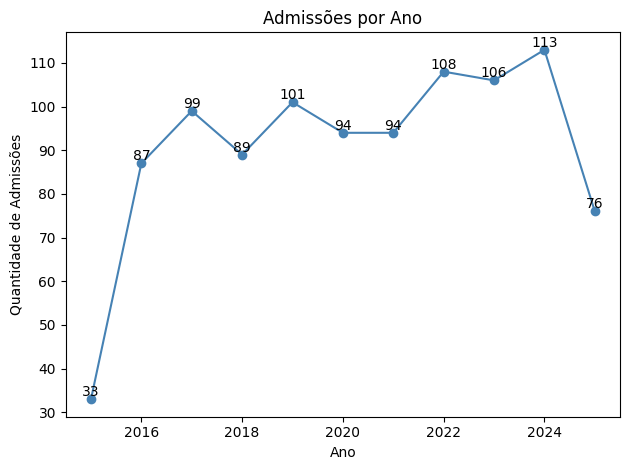

In [17]:
# Usa um gráfico de linha para mostrar a tendência de admissões
plt.plot(
    admissoes_ano["Ano_Admissao"],
    admissoes_ano["Admissoes"],
    marker="o",
    color="steelblue"
)
plt.title("Admissões por Ano")
plt.xlabel("Ano")
plt.ylabel("Quantidade de Admissões")
plt.tight_layout()
#Inserir rótulos
for x, y in zip(admissoes_ano["Ano_Admissao"], admissoes_ano["Admissoes"]):
    plt.text(x, y, str(y), ha='center', va='bottom')
    
plt.show()


### O que este gráfico mostra?
- Cada ponto mostra quantos funcionários foram admitidos em um ano.
- A linha mostra se as admissões aumentam ou diminuem ao longo do tempo.
### Como ler?
- Se a linha sobe, a empresa contratou mais nesse ano.
- Se a linha desce, a empresa contratou menos nesse ano.
### Por que isso importa?
- Ajuda a ver se a empresa está crescendo ou reduzindo contratações.
- Mostra tendências de necessidade de novos funcionários.

## Bloco 2 — merge e pivot_table
`merge` é o JOIN do SQL e `pivot_table` é como criar uma tabela dinâmica em uma linha.


### Exemplo 04 — criando uma tabela de metas e cruzando com o resumo salarial
Use `pd.merge()` para comparar o salário médio real com metas salariais por departamento.


In [18]:
# Cria manualmente a tabela de metas de salário por departamento
metas = pd.DataFrame({
    "Departamento": [
        "Produção", "RH", "Financeiro",
        "Logística", "TI", "Vendas"
    ],
    "Meta_Salario": [9000, 8500, 8200, 8000, 8800, 8000]
})

print("Tabela de metas:")
print(metas.to_string(index=False))


Tabela de metas:
Departamento  Meta_Salario
    Produção          9000
          RH          8500
  Financeiro          8200
   Logística          8000
          TI          8800
      Vendas          8000


In [22]:
# A tabela resumo foi criada no início, mas vamos mostrar só as colunas de departamento e salário médio para comparar com as metas
print(resumo[["Departamento", "media"]].to_string(index=False) + "\n")

# Cruza o resumo salarial com a tabela de metas
comparacao = pd.merge(
    resumo[["Departamento", "media"]],  # seleciona só as colunas de departamento e salário médio do resumo
    metas,                              # tabela de metas criada manualmente
    on="Departamento",                  # chave de junção é a coluna "Departamento"
    how="inner"                         # Mantém só os departamentos que existem em ambas as tabelas, ou seja, os que têm meta definida
)

# Calcula a diferença entre o salário médio real e a meta
comparacao["Diferenca"] = (comparacao["media"] - comparacao["Meta_Salario"]).round(2)   # nova coluna que mostra se o salário médio está acima ou abaixo da meta, arredondada para 2 casas decimais

# A coluna "Status_Meta" recebe um emoji de check verde se a diferença for zero ou positiva (salário médio igual ou acima da meta) e um emoji de X vermelho se a diferença for negativa (salário médio abaixo da meta)
comparacao["Status_Meta"] = comparacao["Diferenca"].apply(
    lambda x: "✅ Acima" if x >= 0 else "❌ Abaixo"
)

print(comparacao.to_string(index=False))


Departamento   media
    Produção 8968.73
   Logística 8881.66
          RH 8791.58
  Financeiro 8333.12
      Vendas 8317.08
          TI 8142.91

Departamento   media  Meta_Salario  Diferenca Status_Meta
    Produção 8968.73          9000     -31.27    ❌ Abaixo
   Logística 8881.66          8000     881.66     ✅ Acima
          RH 8791.58          8500     291.58     ✅ Acima
  Financeiro 8333.12          8200     133.12     ✅ Acima
      Vendas 8317.08          8000     317.08     ✅ Acima
          TI 8142.91          8800    -657.09    ❌ Abaixo


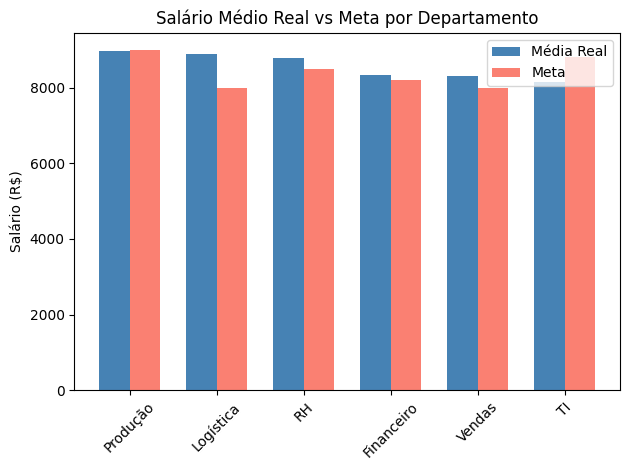

In [25]:
# Usa numpy para posicionar duas barras lado a lado
x = np.arange(len(comparacao))
largura = 0.35

plt.bar(x - largura / 2, comparacao["media"], largura, label="Média Real", color="steelblue")
plt.bar(x + largura / 2, comparacao["Meta_Salario"], largura, label="Meta", color="salmon")
plt.xticks(x, comparacao["Departamento"], rotation=45)
plt.title("Salário Médio Real vs Meta por Departamento")
plt.ylabel("Salário (R$)")
plt.legend()
plt.tight_layout()
# Inserir rótulos
#for i in range(len(comparacao)):
#    plt.text(x[i] - largura / 2, comparacao["media"][i], f'{comparacao["media"][i]}', ha='center', va='bottom')
#    plt.text(x[i] + largura / 2, comparacao["Meta_Salario"][i], f'{comparacao["Meta_Salario"][i]}', ha='center', va='bottom')
plt.show()


### O que este gráfico mostra?
- Cada departamento tem duas barras: uma para o salário médio real e outra para a meta.
- A barra azul mostra o salário médio real e a barra vermelha mostra a meta salarial.
### Como ler?
- Compare as duas barras do mesmo departamento.
- Se a barra real for menor que a meta, o departamento está abaixo do objetivo.
### Por que isso importa?
- Mostra quais departamentos precisam aumentar o salário médio.
- Ajuda a ver onde a meta ainda não foi atingida.

### Exemplo 05 — `pivot_table` para relatório cruzado
`pivot_table` cria uma tabela bidimensional com valores agregados em uma linha de código.


In [26]:
# Cria uma tabela cruzada de salário médio por departamento e cargo
pivot = pd.pivot_table(
    df,                         # DataFrame original
    values="Salario",           # Coluna de valores que queremos agregar
    index="Departamento",       # Coluna que queremos usar como índice (linhas)
    columns="Cargo",            # Coluna que queremos usar para criar as colunas da tabela cruzada
    aggfunc="mean",             # Função de agregação para calcular a média salarial para cada combinação de departamento e cargo
    fill_value=0,               # Preenche com zero as combinações de departamento e cargo que não existem no DataFrame original
).round(0)

print(pivot.to_string())


Cargo         Analista  Assistente  Coordenador  Gerente  Técnico
Departamento                                                     
Financeiro      8022.0      8636.0       8386.0   8129.0   8606.0
Logística       8248.0      9210.0       9252.0   8554.0   9028.0
Produção        9621.0      9937.0       7533.0   9308.0   8658.0
RH              8440.0      8288.0       9826.0   9167.0   7673.0
TI              8556.0      8655.0       8439.0   6959.0   8231.0
Vendas          9071.0      8050.0       8948.0   7935.0   7646.0


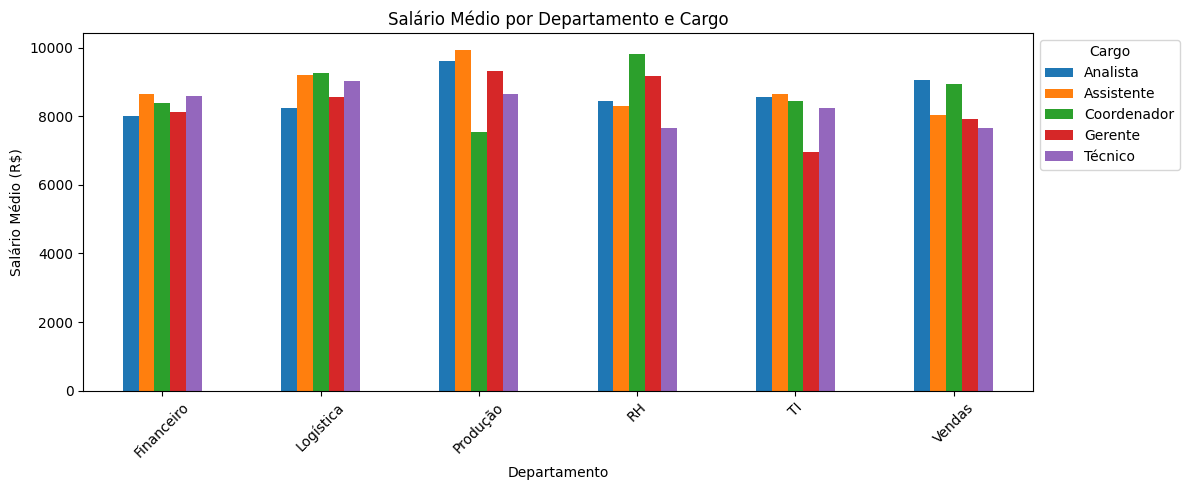

In [27]:
# Plota o resultado do pivot_table em barras agrupadas
pivot.plot(kind="bar", figsize=(12, 5))
plt.title("Salário Médio por Departamento e Cargo")
plt.xlabel("Departamento")
plt.ylabel("Salário Médio (R$)")
plt.xticks(rotation=45)
plt.legend(title="Cargo", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


### O que este gráfico mostra?
- Cada grupo de barras mostra um departamento.
- Cada cor representa um cargo diferente dentro desse departamento.
### Como ler?
- Compare as barras do mesmo departamento para ver quais cargos pagam mais.
- Compare o mesmo cargo entre departamentos para ver diferenças de salário.
### Por que isso importa?
- Mostra quais cargos têm salários maiores ou menores.
- Ajuda a entender diferenças salariais dentro de cada departamento.

## Exercício prático — Dia 02
Complete os passos no notebook usando a base `base_rh.xlsx` e crie os gráficos finais pedindo ao gerente de produção.

1. Carregue `base_rh.xlsx` com `pd.read_excel(URL)` e converta `Data_Admissao` para datetime. Crie `Ano_Admissao` com `.dt.year`.
2. Use `groupby(["Departamento", "Cargo"])` para contar funcionários e exiba o resultado.
3. Use `groupby("Ano_Admissao")` para contar admissões por ano e filtre 2020–2024 com `query()`.
4. Crie uma tabela de metas de headcount por departamento com `pd.DataFrame` e faça `merge left` com o total por departamento. Identifique se a meta foi atingida.
5. Crie um `pivot_table` de `Salario` médio por `Departamento` e `Genero`. Calcule a diferença `F - M`.
6. Plote admissões por ano com `plt.plot(..., marker="o")`.
7. Plote o `pivot_table` de salário médio por gênero com `pivot.plot(kind="bar")`.
8. Faça commit com mensagem `semana 05 - dia 02: groupby, merge, pivot_table, graficos`.


## Gabarito resumido
- Para filtrar anos: `query("Ano_Admissao >= 2020 and Ano_Admissao <= 2024")`.
- Para calcular diferença salarial por gênero: crie `pivot_genero` e depois `pivot_genero["Diferenca_F_M"] = (pivot_genero["F"] - pivot_genero["M"]).round(2)`.
- Use `bbox_to_anchor=(1, 1)` se a legenda cobrir o gráfico.


## Observações finais
Hoje você aprendeu: `groupby` com múltiplas funções, `reset_index()` após groupby, `unstack()` para barras agrupadas, `merge` para cruzar tabelas e `pivot_table` para relatório cruzado.
